## 1. Team Formation and Dataset

This repository will be used by the team **Waveform Warriors** to collaborate on the Data Analysis Final assignment.

Team consists of:

- Juanith Mathew Thomas
- Kornel Lengl

We will work on analysing **Rossmann Store Sales** found on Kaggle: https://www.kaggle.com/datasets/pratyushakar/rossmann-store-sales

The *train.csv* and *test.csv* datasets have several entries of 1115 stores, their sales, ongoing discounts, etc. over a period of about 3 years. <br>
Features like their competitor stores and distance to them are also mentioned in the metadata dataset *store.csv.*

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import *
import matplotlib.pyplot as plt
from random import *
import seaborn as sns

In [3]:
df_complete = pd.read_csv("data/train.csv", low_memory=False)

In [4]:
df_tail = df_complete.tail(n=406975)                        # Taking 365 day sales of each 1115 stores. Data in head is skewed.
df_head = df_complete.head(n=406975)

df = df_tail.drop(df_tail[df_tail['Store'] == 1115].index[0])
# insertion = df_head[df_head['Store'] == 988].sample(1, random_state=42)
# df = pd.concat([df, insertion], ignore_index=True)

df                                                          # This dataset will be used moving forward.

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
610235,1,2,31-12-2013,2362,298,1,0,0,1
610236,2,2,31-12-2013,2148,268,1,0,0,1
610237,3,2,31-12-2013,4081,463,1,0,0,1
610238,4,2,31-12-2013,9813,1323,1,0,0,1
610239,5,2,31-12-2013,2009,241,1,0,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,01-01-2013,0,0,0,0,a,1
1017205,1112,2,01-01-2013,0,0,0,0,a,1
1017206,1113,2,01-01-2013,0,0,0,0,a,1
1017207,1114,2,01-01-2013,0,0,0,0,a,1


## 2. Task Categories and Points

### 2.1: Data Preprocessing and Data Quality


#### • Dataset overview

In [5]:
print ("1. The dimensions of the dataset are: ", df.shape, end="\n\n")                                              # Dimensions
print ("2. The columns in this dataset are: ", df.columns.values, end="\n\n")                                       # Columns
print ("3. The data type of each feature in this dataset: \n" + df.dtypes.to_string(), end="\n\n")                  # Types
print (f"4. Time series range of this dataset is from {min(df['Date'])} to {max(df['Date'])}", end="\n\n")          # Time range
print ("5. The sampling rate of the data is 1 day. Each store tracks and report the daily sales.")      # Sampling rate

1. The dimensions of the dataset are:  (406974, 9)

2. The columns in this dataset are:  ['Store' 'DayOfWeek' 'Date' 'Sales' 'Customers' 'Open' 'Promo'
 'StateHoliday' 'SchoolHoliday']

3. The data type of each feature in this dataset: 
Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64

4. Time series range of this dataset is from 01-01-2013 to 31-12-2013

5. The sampling rate of the data is 1 day. Each store tracks and report the daily sales.


In [6]:
missing_count = df.isnull().sum()
print (f"6. Missingness summary: \n{missing_count}")                                                                # Missingness summary

6. Missingness summary: 
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


#### • Basic statistical analysis using pandas 

In [7]:
print ("1. Description of the dataset: ")                      # Descriptives
df.describe()

1. Description of the dataset: 


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,406974.000000,406974.000000,406974.000000,406974.000000,406974.000000,406974.000000,406974.000000
mean,557.998943,3.994525,5658.533675,629.043686,0.830380,0.369864,0.188774
std,321.872731,1.999995,3821.166174,464.764530,0.375299,0.482768,0.391329
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,279.000000,2.000000,3615.000000,394.000000,1.000000,0.000000,0.000000
50%,558.000000,4.000000,5598.000000,603.000000,1.000000,0.000000,0.000000
75%,837.000000,6.000000,7691.000000,833.000000,1.000000,1.000000,0.000000
max,1115.000000,7.000000,38025.000000,7388.000000,1.000000,1.000000,1.000000


In [8]:
print ("2. Grouped stats of the dataset: ")                    # Grouped stats
df.info()                                                      # Not sure if this is exactly what's expected.

2. Grouped stats of the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406974 entries, 610235 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Store          406974 non-null  int64 
 1   DayOfWeek      406974 non-null  int64 
 2   Date           406974 non-null  object
 3   Sales          406974 non-null  int64 
 4   Customers      406974 non-null  int64 
 5   Open           406974 non-null  int64 
 6   Promo          406974 non-null  int64 
 7   StateHoliday   406974 non-null  object
 8   SchoolHoliday  406974 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 27.9+ MB


In [9]:
Q1 = df['Sales'].quantile(0.25)                                # Quantiles and the IQR value
Q2 = df['Sales'].quantile(0.50)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 = {Q1}")
print(f"Median = {Q2}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")

Q1 = 3615.0
Median = 5598.0
Q3 = 7691.0
IQR = 4076.0


#### • Original data quality analysis with visualization 

In [10]:
missing = df.isnull().sum()                                     # Missingness patterns
missing_pct = (missing / len(df)) * 100

missing_pct

Store            0.0
DayOfWeek        0.0
Date             0.0
Sales            0.0
Customers        0.0
Open             0.0
Promo            0.0
StateHoliday     0.0
SchoolHoliday    0.0
dtype: float64

In [11]:
for col in df.select_dtypes(include=['number']).columns:        # Outliers
    if col == "Open":
        print("Open:            These are binary values, so applying IQR on them is basically useless.")
        print(f"  0: {sum(df['Open'] == 0)} rows, 1: {sum(df['Open'] == 1)} rows")
    
    elif col == "Promo":
        print("Promo:")
        print(f"  0: {sum(df['Promo'] == 0)} rows, 1: {sum(df['Promo'] == 1)} rows")

    elif col == "SchoolHoliday":
        print("SchoolHoliday:")
        print(f"  0: {sum(df['SchoolHoliday'] == 0)} rows, 1: {sum(df['SchoolHoliday'] == 1)} rows")

    else:
        print(f"{col}:")
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR                                  # 'StateHoliday' and 'Date' not included since those are objects, not numeric data types.
        
        out_low  = df[df[col] < lower].shape[0]
        out_high = df[df[col] > upper].shape[0]
        
        print(f"  Range: {df[col].min():.2f} → {df[col].max():.2f}")
        print(f"  IQR outlier bounds: {lower:.2f} ↔ {upper:.2f}")
        print(f"  Outliers: {out_low} below, {out_high} above")

Store:
  Range: 1.00 → 1115.00
  IQR outlier bounds: -558.00 ↔ 1674.00
  Outliers: 0 below, 0 above
DayOfWeek:
  Range: 1.00 → 7.00
  IQR outlier bounds: -4.00 ↔ 12.00
  Outliers: 0 below, 0 above
Sales:
  Range: 0.00 → 38025.00
  IQR outlier bounds: -2499.00 ↔ 13805.00
  Outliers: 0 below, 11167 above
Customers:
  Range: 0.00 → 7388.00
  IQR outlier bounds: -264.50 ↔ 1491.50
  Outliers: 0 below, 15372 above
Open:            These are binary values, so applying IQR on them is basically useless.
  0: 69031 rows, 1: 337943 rows
Promo:
  0: 256449 rows, 1: 150525 rows
SchoolHoliday:
  0: 330148 rows, 1: 76826 rows


In [12]:
exact_dup_rows = df.duplicated(keep=False).sum()                # Duplicate entries
print(f"Exact duplicate rows: {exact_dup_rows} out of {len(df)}")

Exact duplicate rows: 0 out of 406974


In [13]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)                         # Timestamp gaps
sorted_time = df['Date'].dropna().sort_values()
time_gaps = sorted_time.diff()

print(f"Min gap: {time_gaps.min()}")
print(f"Max gap: {time_gaps.max()}")
print(f"Mean gap (of the whole dataset): {time_gaps.mean()}")

random_shop = randint(1, 1115)
dates_series = pd.Series(df[df['Store'] == random_shop]['Date'].sort_values().unique())
print(f"\nMean gap (of shop no. {random_shop}): {dates_series.diff().mean()}")

Min gap: 0 days 00:00:00
Max gap: 1 days 00:00:00
Mean gap (of the whole dataset): 0 days 00:01:17.276870947

Mean gap (of shop no. 195): 1 days 00:00:00


In [14]:
# Only the columns 'Sales' can have inconsistent units.
Serial = 0
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
lowerlimit = Q1 - 1.5 * (Q3 - Q1)
upperlimit = Q3 + 1.5 * (Q3 - Q1)

for sales in df['Sales']:
    if sales > upperlimit:
        Serial += 1

print (f"Number of outlier sales days {Serial} out of {len(df['Sales'])}")

# The dataset was obtained from Kaggle.
# Metadata has confirmed that all the stores from which the data was obtained were German stores.
# It is reasonably safe to assume all sales were in Euros since there's no great way of figuring out inconsistent units.
# Outliers do exist but nothing too drastic to suggest sale reports in a considerably weaker currency.

Number of outlier sales days 11167 out of 406974


#### • Data preprocessing pipeline

In [15]:
df_clean = df[df['Sales'] > 0].reset_index(drop=True)                       # Cleaning steps
remaining_stores = len(df) - len(df_clean)

print(f"Removed {remaining_stores} closed store days ({100*(remaining_stores)/len(df):0.2f}%)")

Removed 69050 closed store days (16.97%)


In [16]:
print(df_clean.isnull().sum())                                              # No missing data

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


In [17]:
df_clean_again = df_clean[(df_clean['Sales'] >= lowerlimit) & (df_clean['Sales'] <= upperlimit)]
remaining_stores = len(df_clean) - len(df_clean_again)                      # Removing outliers

print(f"Removed {remaining_stores} outlier store entries ({100*(remaining_stores)/len(df):0.2f}%)")

Removed 11167 outlier store entries (2.74%)


In [29]:
df_clean_again = df_clean_again.copy()                                      # Basic feature engineering
df_clean_again['IsWeekend'] = (df_clean_again['DayOfWeek'] >= 5).astype(int)

In [ ]:
df_complete                         # Original dataframe

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,31-07-2015,5263,555,1,1,0,1
1,2,5,31-07-2015,6064,625,1,1,0,1
2,3,5,31-07-2015,8314,821,1,1,0,1
3,4,5,31-07-2015,13995,1498,1,1,0,1
4,5,5,31-07-2015,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,01-01-2013,0,0,0,0,a,1
1017205,1112,2,01-01-2013,0,0,0,0,a,1
1017206,1113,2,01-01-2013,0,0,0,0,a,1
1017207,1114,2,01-01-2013,0,0,0,0,a,1


In [ ]:
df_clean_again                      # Cleaned dataframe

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,IsWeekend
0,1,2,2013-12-31,2362,298,1,0,0,1,0
1,2,2,2013-12-31,2148,268,1,0,0,1,0
2,3,2,2013-12-31,4081,463,1,0,0,1,0
3,4,2,2013-12-31,9813,1323,1,0,0,1,0
4,5,2,2013-12-31,2009,241,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
337919,682,2,2013-01-01,3375,566,1,0,a,1,0
337920,733,2,2013-01-01,10765,2377,1,0,a,1,0
337921,769,2,2013-01-01,5035,1248,1,0,a,1,0
337922,948,2,2013-01-01,4491,1039,1,0,a,1,0


Commentary on what changed in the original vs. cleaned dataset.

Firstly, the size of the dataset reduced. Instead of having 700-1000 entries for each shop, skewed in favor of some, the data was seived to obtain 365 entries of each 1115 shop. <br>
Outliers were removed. Duplicates were checked for, none present. <br>
Days on which stores had 0 sales were removed since they could negatively impact the pattern learning of the LR model. <br>
Feature engineering added 1 feature to the dataset namely 'IsWeekend' which might help the linear regression better predict the sales of a shop that remains open (and has more sales) on the weekend. 

### 2.2: Visualization and Exploratory Analysis

#### • Time-series visualizations

Text(0, 0.5, 'Sales')

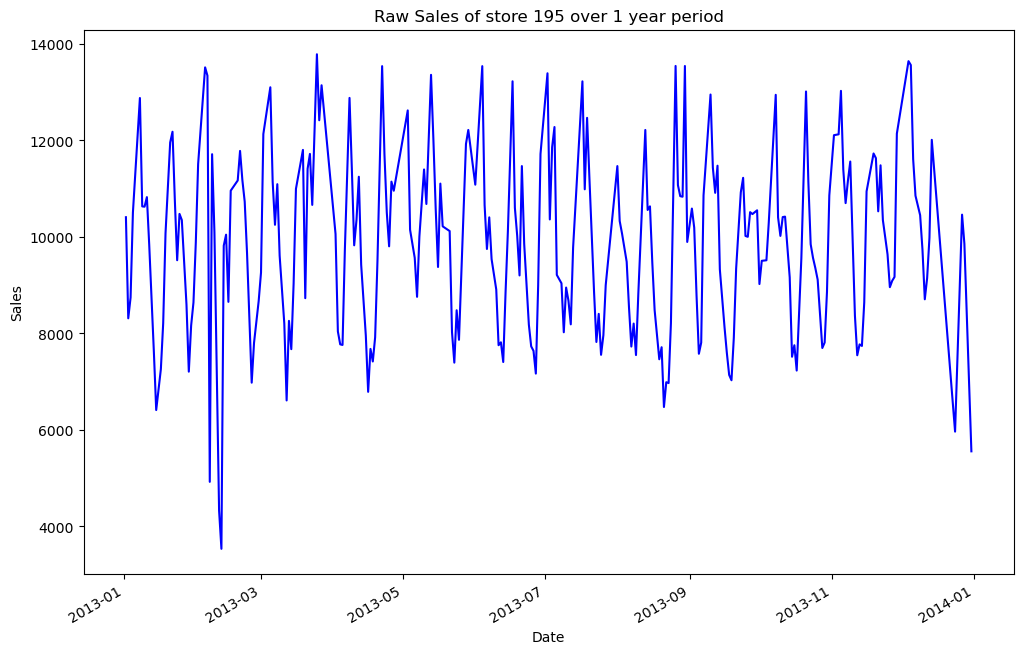

In [21]:
df = df_clean_again               # Reassigning the cleaned dataset to df

store_data = df[df['Store'] == random_shop].copy()
store_data['Date'] = pd.to_datetime(store_data['Date'])
store_data = store_data.sort_values('Date').set_index('Date')

plt.figure(figsize=(12, 8))
store_data['Sales'].plot(title=f"Raw Sales of store {random_shop} over 1 year period", color='blue')       # Raw
plt.ylabel('Sales')

Text(0, 0.5, 'Sales')

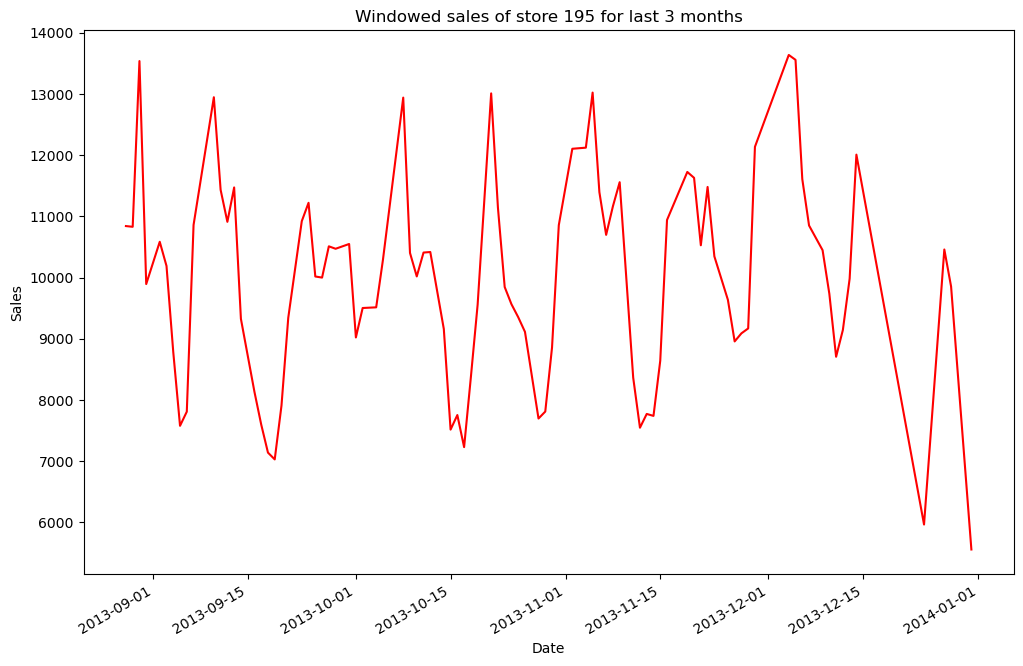

In [22]:
plt.figure(figsize=(12, 8))                                                                                 # Windowed
store_data['Sales'].tail(90).plot(title=f"Windowed sales of store {random_shop} for last 3 months", color='red')
plt.ylabel('Sales')

#### • Distribution analysis with histograms and density style plots 

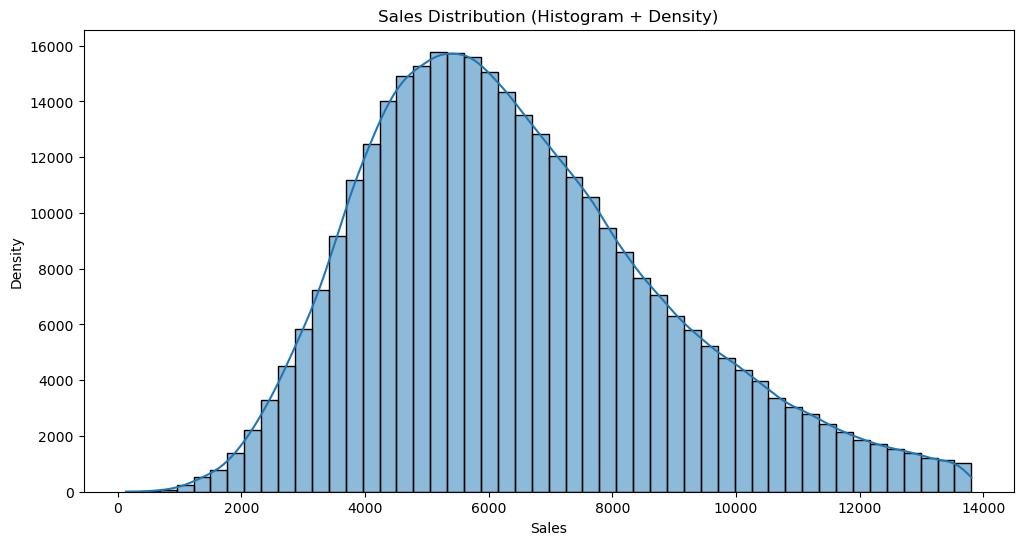

In [30]:
plt.figure(figsize=(12, 6)) 
sns.histplot(data=df, x='Sales', kde=True, bins=50)                 # kernel density estimate (KDE) for the density curve on the bins
plt.title(f'Sales Distribution (Histogram + Density)')
plt.xlabel('Sales')
plt.ylabel('Density')
plt.show()

#### • Correlation analysis and heatmaps

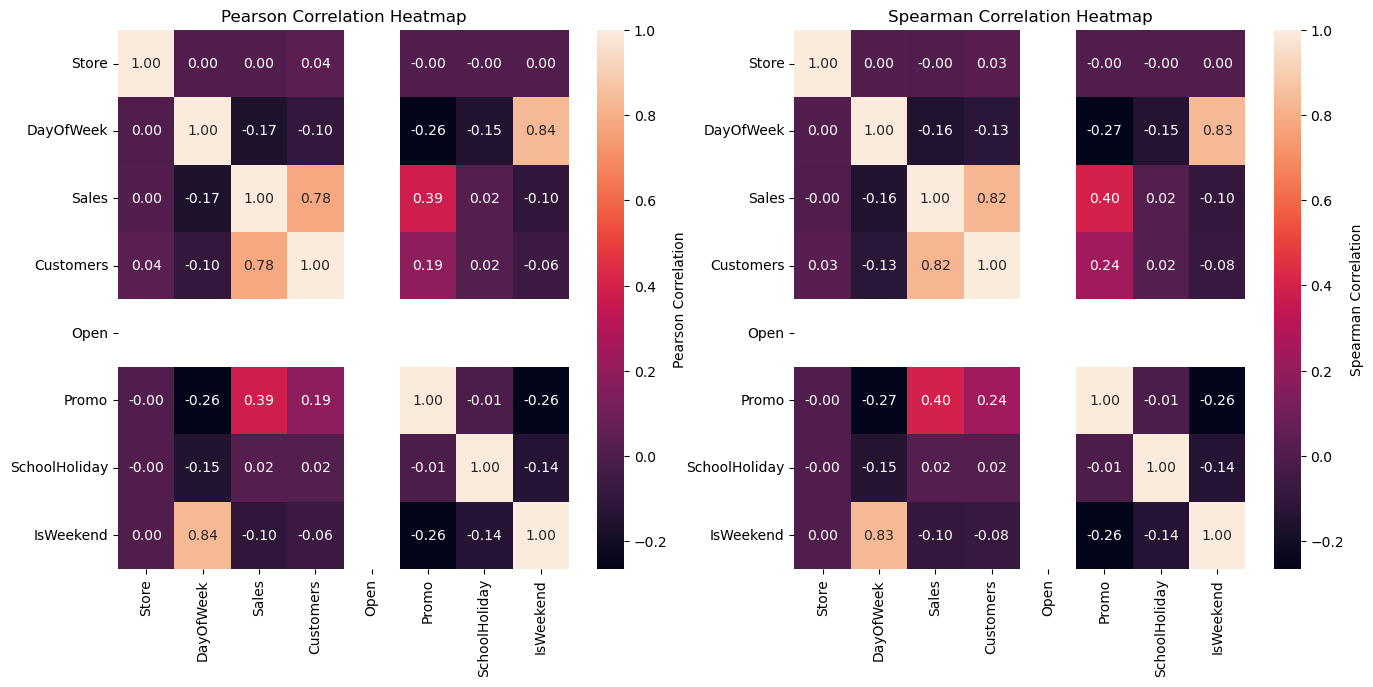

In [31]:
numeric_cols = df.select_dtypes(include=['number']).columns
corr_data = df[numeric_cols]

pearson_corr = corr_data.corr(method='pearson')                             # 1. Pearson correlation
spearman_corr = corr_data.corr(method='spearman')                           # 2. Spearman correlation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(pearson_corr, annot=True, ax=ax1, fmt='.2f', cbar_kws={'label': 'Pearson Correlation'})
ax1.set_title('Pearson Correlation Heatmap')

sns.heatmap(spearman_corr, annot=True, ax=ax2, fmt='.2f', cbar_kws={'label': 'Spearman Correlation'})
ax2.set_title('Spearman Correlation Heatmap')

plt.show()

##### Interpretation of the above heatmaps

As expected, the correlation is quite similar for both in most aspects, subtle differences caused by the difference in method of correlation calculation. <br>
Since our dataset:
1. Doesn't have outliers
2. Is sufficiently large
3. Not skewed towards the tail

Pearson correlation is pretty sufficient for correlation analysis and we don't necessarily need to employ spearman method.

#### • Daily or periodic pattern analysis 

In [35]:
store_data

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,IsWeekend
Date,,,,,,,,,
2013-01-02,195,3,10405,1322,1,0,0,1,0
2013-01-03,195,4,8311,1116,1,0,0,1,0
2013-01-04,195,5,8742,1144,1,0,0,1,1
2013-01-05,195,6,10502,1331,1,0,0,0,1
2013-01-08,195,2,12874,1483,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...
2013-12-14,195,6,12008,1367,1,0,0,0,1
2013-12-24,195,2,5964,817,1,0,0,1,0
2013-12-27,195,5,10458,1355,1,0,0,1,1


In [48]:
store_data = store_data.reset_index()

In [49]:
store_data

,Date,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,IsWeekend
0,2013-01-02,195,3,10405,1322,1,0,0,1,0
1,2013-01-03,195,4,8311,1116,1,0,0,1,0
2,2013-01-04,195,5,8742,1144,1,0,0,1,1
3,2013-01-05,195,6,10502,1331,1,0,0,0,1
4,2013-01-08,195,2,12874,1483,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
263,2013-12-14,195,6,12008,1367,1,0,0,0,1
264,2013-12-24,195,2,5964,817,1,0,0,1,0
265,2013-12-27,195,5,10458,1355,1,0,0,1,1
266,2013-12-28,195,6,9853,1299,1,0,0,0,1


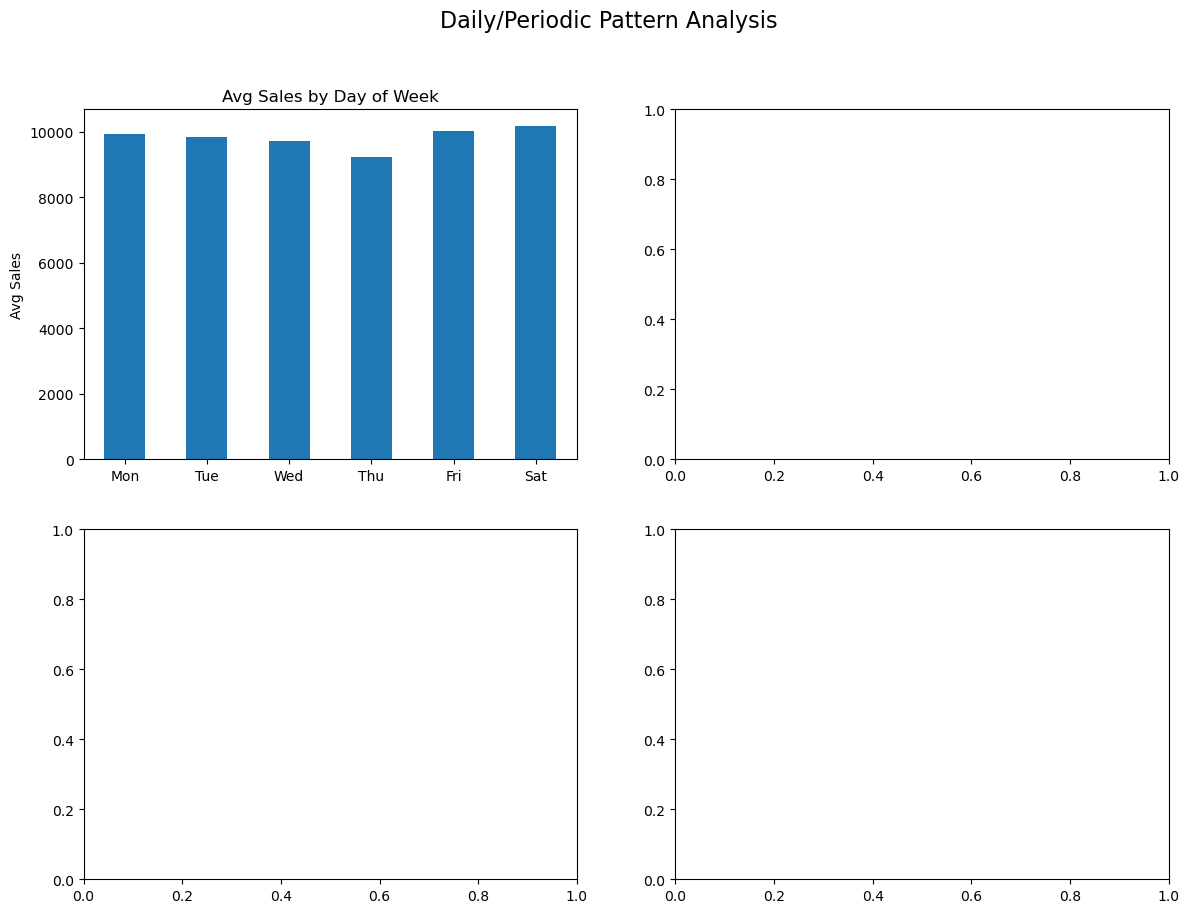

In [51]:
store_data['date'] = pd.to_datetime(store_data['Date'])
store_data['dayOfWeek'] = store_data['Date'].dt.dayofweek
store_data['month'] = store_data['Date'].dt.month

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Daily/Periodic Pattern Analysis', fontsize=16)

day_means = store_data.groupby('DayOfWeek')['Sales'].mean()                             # Day-of-week pattern
day_means.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
day_means.plot(kind='bar', ax=axes[0, 0], title='Avg Sales by Day of Week')
axes[0, 0].set_ylabel('Avg Sales')
axes[0, 0].tick_params(axis='x', rotation=0)